In [ ]:
import oqupy
from oqupy.tti_tempo import TTITempo, TTITempoCounting
from oqupy import operators as op

# first generating corrs for alpha=0.1
params = [0.25,8,50]

dt = params[0]
print(dt)
epsrel_pow = int(params[1])
epsrel = 10**(-epsrel_pow)  # convert to float
tcut= 500  # tcut (int)

pt_parameters = {'epsrel':epsrel,
                 'alpha':0.1,
                 'omega_cutoff':1,                 
                 'temp':0.131,
                 'dt':dt,
                 'tcut':tcut}


omega_cutoff = pt_parameters['omega_cutoff']
alpha = pt_parameters['alpha']
temperature = pt_parameters['temp']

tcut=pt_parameters['tcut']

Rho_0=oqupy.operators.spin_dm("x+")

# spectral density (without cutoff)
def j(w):
    return 2*alpha*w

correlations = oqupy.PowerLawSD(alpha=alpha,
                                zeta=1,
                                cutoff=omega_cutoff,
                                cutoff_type='exponential',
                                temperature=temperature)
bath = oqupy.Bath(op.sigma("z")/2.0, correlations)
parameters=oqupy.TempoParameters(dt=dt,epsrel=epsrel,dkmax=int(tcut/dt)+1)

u=0.01
correlationscf=oqupy.bath_correlations.CustomCountingSD_analytical(j_function=j,cutoff=omega_cutoff,u=u,
                                                 cutoff_type='exponential',temperature=temperature)

bathcf = oqupy.Bath(op.sigma("z")/2.0, correlationscf)

#num_steps=int(t_arg/dt)

pt= TTITempo(bath,start_time=0.0,parameters=parameters)
processtensor= pt.get_process_tensor()

pt_cf=TTITempoCounting(bathcf,start_time=0.0,parameters=parameters)
processtensorcf = pt_cf.get_process_tensor()

0.25


building influence functional: 100%|██████████| 2001/2001 [00:01<00:00, 1222.76it/s]


rank  72


building influence functional: 100%|██████████| 2001/2001 [00:03<00:00, 600.52it/s]

rank  76


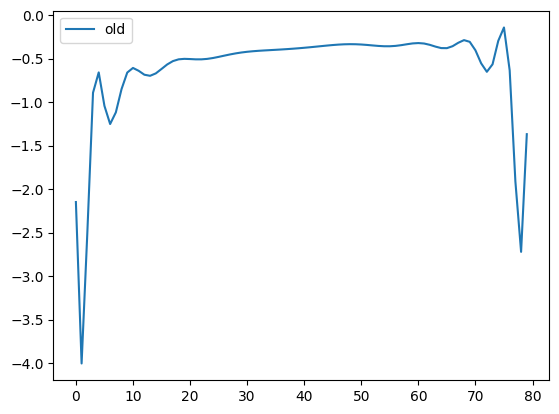

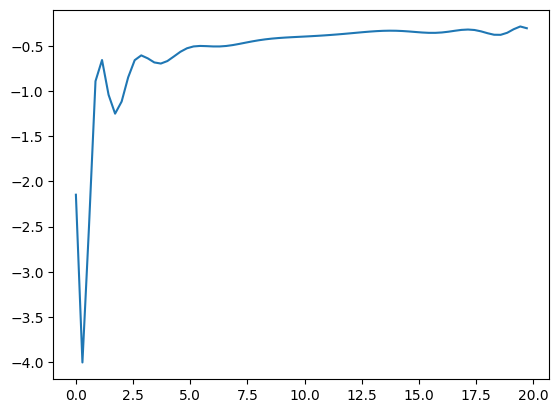

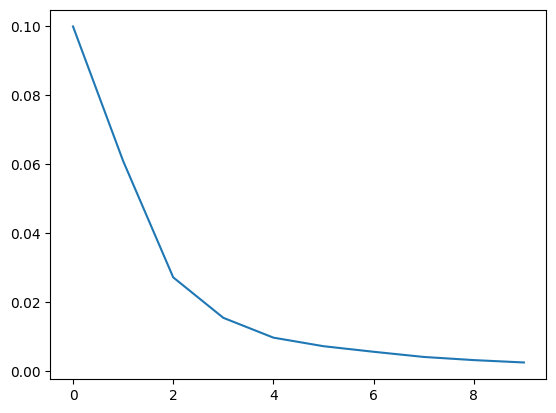

In [24]:
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import dill
import numpy as np

t_prot=20

#'results/zero_control_lowercoupling/dt=0.25_ps=-8.0_tcut=30_alpha=0.05/{0}ps'
#folder='results/zero_control/{0}ps/optimization_simplemodel_{0}ps/dt=0.25_ps=-8.0_tcut=500'
#with open('results/zero_control/{0}ps/optimization_simplemodel_{0}ps'.format(t_prot), 'rb') as f:

with open('results/zero_control/{0}ps/optimization_simplemodel_{0}ps'.format(t_prot), 'rb') as f:
    opt_dict_old = dill.load(f)

plt.plot(opt_dict_old['result'].x,label='old')
plt.legend()
plt.show()

opt_control = opt_dict_old['result'].x[:-10]
dt_control = t_prot / len(opt_control)
control_times = np.linspace(0, t_prot, len(opt_control), endpoint=False)

delta_t = interp1d(control_times, opt_control, kind='previous', fill_value="extrapolate")

plt.plot(control_times, opt_control)
plt.show()

num_its=np.shape(opt_dict_old['log'])
heat_log_old=[opt_dict_old['log'][i]['final heat'] for i in range(num_its[0])]
plt.plot(heat_log_old)
plt.show()

In [25]:
def hamiltonian_t(t):
    return delta_t(t)*oqupy.operators.sigma("x")/2 #if analytic propagators used no fcator of 0.5

system = oqupy.TimeDependentSystem(hamiltonian_t)

In [56]:

def w(theta):
    if np.abs(theta)<0.1:
        return 1.0-theta**2/12+theta**4/360-theta**6/20160
    else:
        return 2*(1-np.cos(theta))/(theta**2)
    
def alpha0(theta):
    if np.abs(theta)<0.1:
        return -0.5+theta**2/24-theta**4/720+theta**6/40320 + \
            1.0j*theta*(1.0/6.0-theta**2/120+theta**4/5040-theta**6/362880)
    else:
        return -(1-np.cos(theta))/(theta**2)+1.0j*(theta-np.sin(theta))/theta**2

def trapezoidal_fft_integral(samples,a,delta,n):
    r'''
    Numerically computes the Fourier integral $\int_a^b e^{i\omega t} f(t)$, using the FFT with endpoint corrections.
    Function f(t) is given as the array samples, where samples[k] is the value of the function at the time $a+k*\delta$.
    $a$ is the lower limit of integral
    $\Delta$ is the time spacing.
    n is the number of points at which to compute the Fourier transform, which is adjusted to an even number.
    It should be chosen so as to oversample the function f(t) by a sufficient factor. 
    Note that the upper limit $b=a+m\Delta$, where m=samples.shape[0]-1, i.e. the maximum time in the array.
    Returns omegas,dftres, where omegas are the angular frequencies at which the result is computed, and dftres the result.
    These are in the scrambled FFT order and can be unscrambled into the usual order with np.fft.fftshift.
    '''
    m=samples.shape[0]-1 # largest index of the data
    assert (n>=(m+1))
    if (n%2==1):
        n=n+1
    print(n)
    thetas=np.fft.fftfreq(n)*2*np.pi
    omegas=thetas/delta    
    ws=np.vectorize(w)(thetas)
    a0s=np.vectorize(alpha0)(thetas)
    dftres=np.fft.ifft(samples,n=n,norm="forward")
    dumbway=np.copy(dftres)
    dftres=delta*np.exp(1.0j*omegas*a)*(dftres*ws+a0s*samples[0]+
                                        +np.conjugate(a0s)*samples[m]*np.exp(1.0j*omegas*(m*delta-a)))
    return omegas,dftres,delta*dumbway

In [27]:
processtensor._len=int(t_prot/dt)
processtensor.length=int(t_prot/dt)
print(len(processtensor))
bath_corr = oqupy.bath_dynamics.TwoTimeBathCorrelations(system, bath, processtensor, Rho_0)


80


In [28]:
bath_corr.generate_system_correlations(20)

--> Compute correlations:
100.0%   80 of   80 [########################################] 00:25:48
Elapsed time: 1548.1s


In [59]:
cfarr=np.array(bath_corr._system_correlations)
print(np.shape(cfarr))
cfarr[np.isnan(cfarr)] = 0

def plotdispl2(time,natten):
    tsforplot=int(time//dt)
    tindx=tsforplot
    n=np.shape(cfarr[:,tindx])[0]#6000
    pstep=1
    tdat=cfarr[:(tindx+1),tindx]
    #natten=tindx/natten
    attenfactor=np.exp(np.arange(-tindx,1)/natten)
    tdat=tdat*attenfactor
    allomega,ftcfarr,ftcarrdumb=trapezoidal_fft_integral(tdat, 0, dt, n)
    
    omega=allomega[0:n//2]
    disps=ftcfarr[0:n//2]
    dispsdumb=ftcarrdumb[0:n//2]
    
    # multiply by the spectral density.
    
    disps=-2.0j*disps*correlations.spectral_density(omega)

    dispsdumb=dispsdumb*correlations.spectral_density(omega)
    
    dispsdumb=-2.0j*np.exp(-1.0j*tindx*dt)*dispsdumb
    
    # compare with displacements in the polaron state
    plt.plot(omega[::pstep],np.abs(disps)[::pstep],label='OQuPy')
    plt.plot(omega[::pstep],np.abs(dispsdumb)[::pstep],label='OQuPy-Simple FFT')
    plt.xlabel(r'$\omega$ (ns$^{-1}$)')
    plt.ylabel(r'$|f(\omega)|^2$ (ns)')
    plt.text(0.8,0.5,r'$\alpha$=0.1',transform=plt.gca().transAxes)
    t=tindx*dt
    plt.text(0.8,0.4,rf't={t:.1f}',transform=plt.gca().transAxes)
    plt.legend()
    print(np.max(np.abs(disps-dispsdumb)))

    return omega[::pstep],np.abs(disps)[::pstep]


(80, 80)


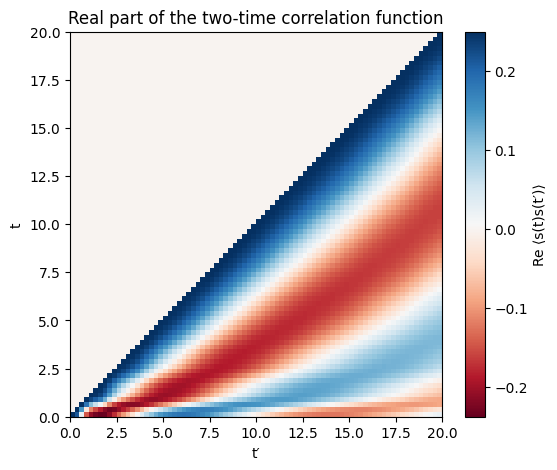

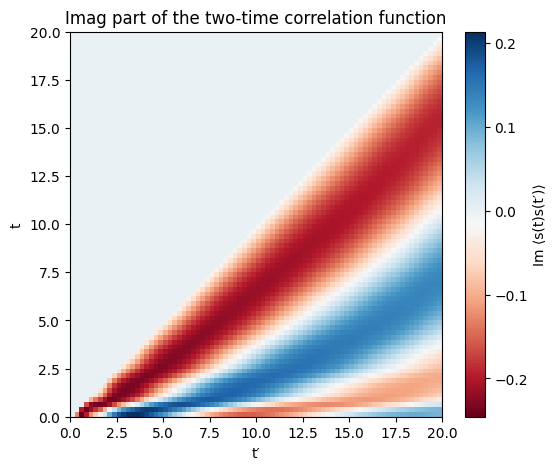

In [40]:
t=np.linspace(0, t_prot, int(t_prot/dt)+1)

T, Tprime = np.meshgrid(t, t) 
plt.figure(figsize=(6,5))
plt.pcolormesh(T, Tprime, np.real(cfarr), shading='auto', cmap='RdBu')
plt.colorbar(label='Re ⟨s(t)s(t′)⟩')
plt.xlabel("t′")
plt.ylabel("t")
plt.title("Real part of the two-time correlation function")
plt.show()

plt.figure(figsize=(6,5))
plt.pcolormesh(T, Tprime, np.imag(cfarr), shading='auto', cmap='RdBu')
plt.colorbar(label='Im ⟨s(t)s(t′)⟩')
plt.xlabel("t′")
plt.ylabel("t")
plt.title("Imag part of the two-time correlation function")
plt.show()



In [41]:
np.allclose(np.real(cfarr), np.real(cfarr.T))       # should be True
np.allclose(np.imag(cfarr), -np.imag(cfarr.T))      # should be True


False

80
0.009181174249258746
80
0.07113464885395997
80
0.0033723932307170895


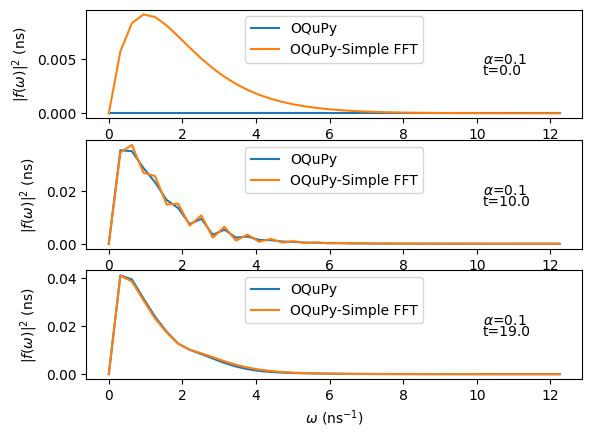

In [42]:
fig,ax=plt.subplots(nrows=3,ncols=1)

plt.sca(ax[0])
plotdispl2(0,200)
plt.sca(ax[1])
plotdispl2(10,200)
plt.sca(ax[2])
plotdispl2(19,200)
plt.show()

2000
--> Compute correlations:
  0.0%    0 of  400 [----------------------------------------] 00:00:059
Elapsed time: 5.2s
  0.2%   40 of 19990 [----------------------------------------] 00:52:28

KeyboardInterrupt: 

  0.7%  137 of 19990 [----------------------------------------] 00:52:42

  0.7%  137 of 19990 [----------------------------------------] 00:52:51

dict_keys(['result', 'log', 'fidelitygrad', 'opttime', 'parameters'])


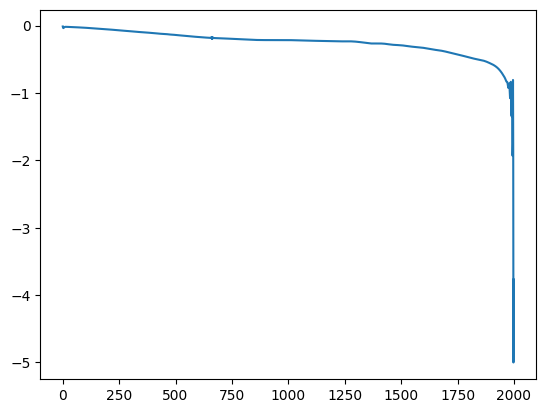

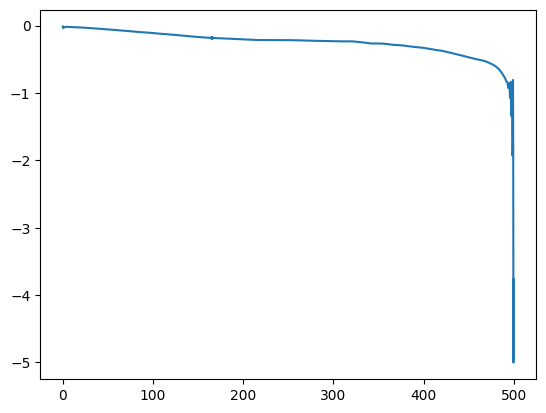

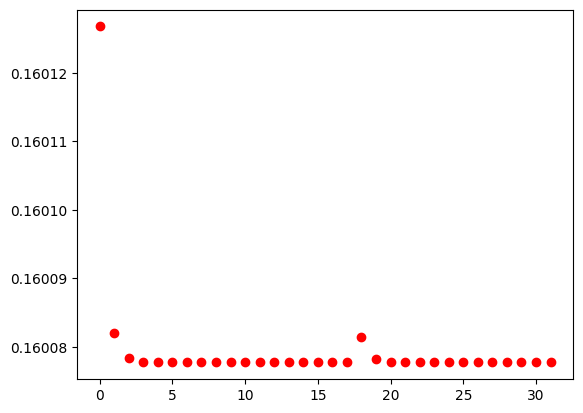

In [8]:
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

t_prot=500

with open('results/forward_erasure/dt=0.25_ps=-8.0_tcut=500_alpha=0.05_nonzero/{0}ps'.format(t_prot), 'rb') as f:
    opt_dict = dill.load(f)
print(opt_dict.keys())
plt.plot(opt_dict['result'].x[0::3])
plt.show()

opt_control = opt_dict['result'].x[0::3]
dt_control = t_prot / len(opt_control)
control_times = np.linspace(0, t_prot, len(opt_control), endpoint=False)

delta_t = interp1d(control_times, opt_control, kind='previous', fill_value="extrapolate")

plt.plot(control_times, opt_control)
plt.show()

num_its=np.shape(opt_dict['log'])
heat_log=[opt_dict['log'][i]['final heat'] for i in range(10,num_its[0])]
plt.plot(heat_log,'ro')
plt.show()

0.25
20
80
--> Compute dynamics:


100.0%   80 of   80 [########################################] 00:00:21
Elapsed time: 21.5s
--> Compute dynamics:
100.0%   80 of   80 [########################################] 00:00:20
Elapsed time: 20.1s


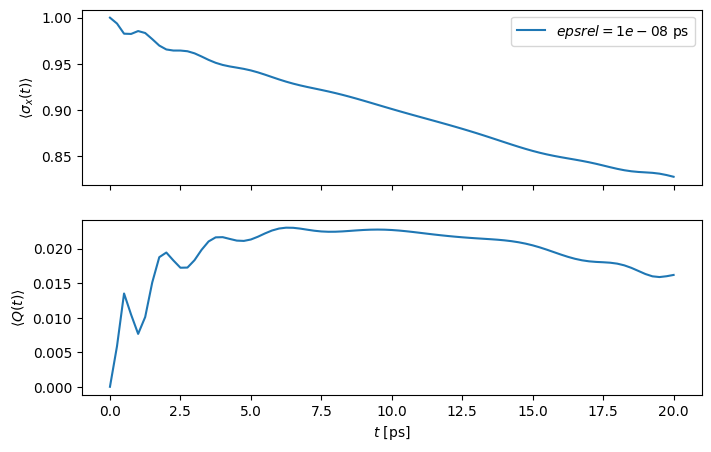

In [44]:
fig, axs = plt.subplots(2, figsize=(8, 5), sharex=True)
num_steps = int(t_prot/dt)
print(dt)
print(t_prot)
def hamiltonian_t(t):
    return delta_t(t)*oqupy.operators.sigma("x")/2
print(num_steps)
system = oqupy.TimeDependentSystem(hamiltonian_t)

dynamics = oqupy.compute_dynamics(
    process_tensor=processtensor,
    system=system,
    initial_state=Rho_0,
    start_time=0,
    num_steps=num_steps)

dynamicscf = oqupy.compute_dynamics(
    process_tensor=processtensorcf,
    system=system,
    initial_state=Rho_0,
    start_time=0,
    num_steps=num_steps)

t,final_x = dynamics.expectations(op.sigma('x'), real=True)
final_Q = dynamicscf.states.trace(axis1=1, axis2=2).imag / 0.01
axs[0].plot(t,final_x,'-',label=r'$epsrel={0}$ ps'.format(epsrel))
axs[1].plot(t,final_Q,'-')

axs[0].legend()
axs[0].set_ylabel(r'$\langle \sigma_x (t) \rangle$')
axs[1].set_ylabel(r'$\langle Q (t) \rangle$')
axs[1].set_xlabel(r'$ t$ [ps]')

plt.show()

In [45]:

# define bath frequencies and couplings
omega_k = np.linspace(0.01, 5*omega_cutoff, 200)  # discretized modes
J = 2 * np.pi * alpha * omega_k * np.exp(-omega_k / omega_cutoff)
g_k = np.sqrt(J * (omega_k[1]-omega_k[0]) / np.pi)

dt = t[1] - t[0]
b_k = np.zeros((len(omega_k), len(t)), dtype=complex)

for i, omega in enumerate(omega_k):
    kernel = np.exp(-1j * omega * (t[:, None] - t[None, :]))
    kernel = np.triu(kernel)  # enforce causal integration
    b_k[i] = -1j * g_k[i] * np.sum(kernel * final_x[None, :] * dt, axis=1)

# real-space displacement (position quadrature)
x_k = b_k + b_k.conj()

# at final time:
x_final = np.real(x_k[:, -1])


In [46]:

# Given:
# t: time array (shape N)
# s_t: expectation value of system operator <s(t)> (shape N)
# alpha, omega_c: bath parameters
# t_final: final time of interest

# Parameters
omega_k = np.linspace(0.01, 5 * omega_cutoff, 200)  # bath frequencies
J = 2 * np.pi * alpha * omega_k * np.exp(-omega_k / omega_cutoff)  # Ohmic SD
dt = t[1] - t[0]

# Compute the time integral for each frequency
# f(omega,t) = -2i * J(omega) ∫_0^t e^{-i ω (t - t')} s(t') dt'
f_omega_t = np.zeros((len(omega_k), len(t)), dtype=complex)

for i, omega in enumerate(omega_k):
    # causal kernel for each omega
    kernel = np.exp(-1j * omega * (t[:, None] - t[None, :]))
    kernel = np.triu(kernel)  # ensure t' <= t
    f_omega_t[i] = -2j * J[i] * np.sum(kernel * final_x[None, :] * dt, axis=1)




In [63]:
plt.sca(ax[0])
plotdispl2(0,200)
plt.sca(ax[1])
plotdispl2(10,200)
plt.sca(ax[2])
w,d=plotdispl2(0,200)
plt.show()

80


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

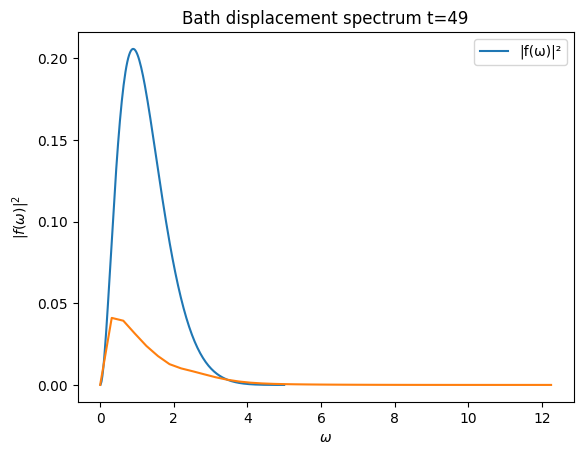

In [61]:
# Spectrum at the final time
f_final = f_omega_t[:, int(19/dt)]
spectrum = np.abs(f_final)**2

# Plot
plt.figure()
plt.plot(omega_k, spectrum, label='|f(ω)|²')
plt.plot(w,d)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$|f(\omega)|^2$')
plt.title('Bath displacement spectrum t=49')
plt.legend()
plt.show()

In [49]:
import numpy as np
import matplotlib.pyplot as plt

# --- Copied helper functions (unchanged) ---
def w(theta):
    if np.abs(theta) < 0.1:
        return 1.0 - theta**2 / 12 + theta**4 / 360 - theta**6 / 20160
    else:
        return 2 * (1 - np.cos(theta)) / (theta**2)

def alpha0(theta):
    if np.abs(theta) < 0.1:
        return -0.5 + theta**2 / 24 - theta**4 / 720 + theta**6 / 40320 + \
            1.0j * theta * (1.0 / 6.0 - theta**2 / 120 + theta**4 / 5040 - theta**6 / 362880)
    else:
        return -(1 - np.cos(theta)) / (theta**2) + 1.0j * (theta - np.sin(theta)) / (theta**2)

def trapezoidal_fft_integral(samples, a, delta, n):
    m = samples.shape[0] - 1
    assert n >= (m + 1)
    if n % 2 == 1:
        n = n + 1
    thetas = np.fft.fftfreq(n) * 2 * np.pi
    omegas = thetas / delta
    ws = np.vectorize(w)(thetas)
    a0s = np.vectorize(alpha0)(thetas)
    dftres = np.fft.ifft(samples, n=n, norm="forward")
    dftres = delta * np.exp(1.0j * omegas * a) * (
        dftres * ws + a0s * samples[0] + np.conjugate(a0s) * samples[m] * np.exp(1.0j * omegas * (m * delta - a))
    )
    return omegas, dftres


# --- Bath displacement computation using the FFT integral ---
def bath_displacement_spectrum_fft(t, s_t, alpha, omega_c, t_eval=None, natten=200, nfft=None):
    """
    Compute bath displacement spectrum |f(ω)|² using the same trapezoidal FFT integration method.
    """
    if t_eval is None:
        t_eval = t[-1]
    dt = t[1] - t[0]
    n_eval = int(t_eval / dt)
    
    # Apply attenuation window (as in plotdispl2)
    attenfactor = np.exp(np.arange(-n_eval, 1) / natten)
    s_t_windowed = s_t[:n_eval + 1] * attenfactor

    # Choose FFT length
    if nfft is None:
        nfft = 8 * len(s_t_windowed)  # oversampling for smoother ω grid
    
    # Compute Fourier integral ∫₀ᵗ e^{+iω(t−t′)} s(t′) dt′ via trapezoidal FFT
    omegas, F_omegas = trapezoidal_fft_integral(s_t_windowed[::-1], 0.0, dt, nfft)
    
    # Unscramble to normal frequency order
    omegas = np.fft.fftshift(omegas)
    F_omegas = np.fft.fftshift(F_omegas)

    # Shift to match phase convention (t−t′)
    phase = np.exp(1j * omegas * t_eval)
    F_omegas *= phase

    # Ohmic spectral density
    J = 2 * alpha * np.abs(omegas) * np.exp(-np.abs(omegas) / omega_c)

    # Compute displacement f(ω)
    f_omega = -2j * J * F_omegas

    # Spectrum
    spectrum = np.abs(f_omega)**2

    return omegas, spectrum, f_omega


# --- Example usage ---
if __name__ == "__main__":
    # Dummy test data
    t = np.linspace(0, 50, 2000)
    s_t = final_x
    alpha = 0.1
    omega_c = 1

    for t_eval in [10, 25, 49]:
        omegas, spec, _ = bath_displacement_spectrum_fft(t, s_t, alpha, omega_c, t_eval=t_eval)
        plt.plot(omegas, spec, label=fr"$t={t_eval}$")

    plt.xlim(0, 10)
    plt.xlabel(r'$\omega$ (ns$^{-1}$)')
    plt.ylabel(r'$|f(\omega)|^2$ (ns)')
    plt.title("Bath displacement spectrum via trapezoidal FFT integral")
    plt.legend()
    plt.show()


ValueError: operands could not be broadcast together with shapes (81,) (400,) 

  1.5%   29 of 2000 [----------------------------------------] 02:59:50

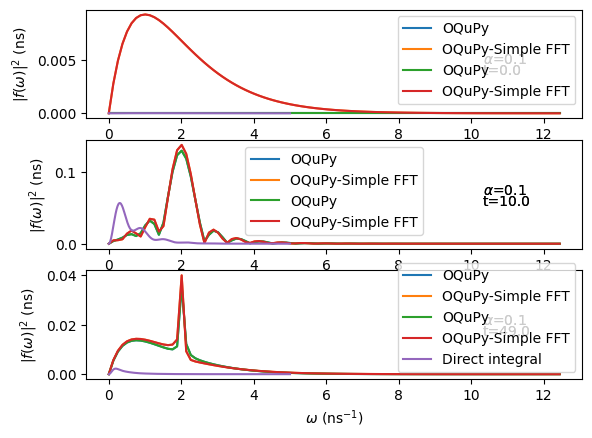

  1.5%   29 of 2000 [----------------------------------------] 03:02:45

In [ ]:
plt.sca(ax[0])
omega_k, spec0, _ = bath_displacement_spectrum(t, s_t, alpha, omega_c, t_eval=0)
plt.plot(omega_k, spec0, label='Direct integral')

plt.sca(ax[1])
omega_k, spec10, _ = bath_displacement_spectrum(t, s_t, alpha, omega_c, t_eval=10)
plt.plot(omega_k, spec10, label='Direct integral')

plt.sca(ax[2])
omega_k, spec49, _ = bath_displacement_spectrum(t, s_t, alpha, omega_c, t_eval=49)
plt.plot(omega_k, spec49, label='Direct integral')

plt.legend()
plt.show()
